In [15]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# Implement baseline algorithm

def baseline_max_sublist(arr):
    max_so_far = float("-inf")

    for i in range(len(arr)):
        current_max = 0

        for j in range(i, len(arr)):
            current_max += arr[j]

            if current_max > max_so_far:
                max_so_far = current_max

    return max_so_far

A = [-2, 3, -1, 4, -5, 2]
baseline_max_sublist(A)

3

In [17]:
# Implement target algorithm

def kadane_max_subarray(A):
    max_so_far = float('-inf')
    current_max = 0

    for x in A:
        current_max += x

        if current_max > max_so_far:
            max_so_far = current_max

        if current_max < 0:
            current_max = 0

    return max_so_far

A = [-2, 3, -1, 4, -5, 2]
kadane_max_subarray(A)

6

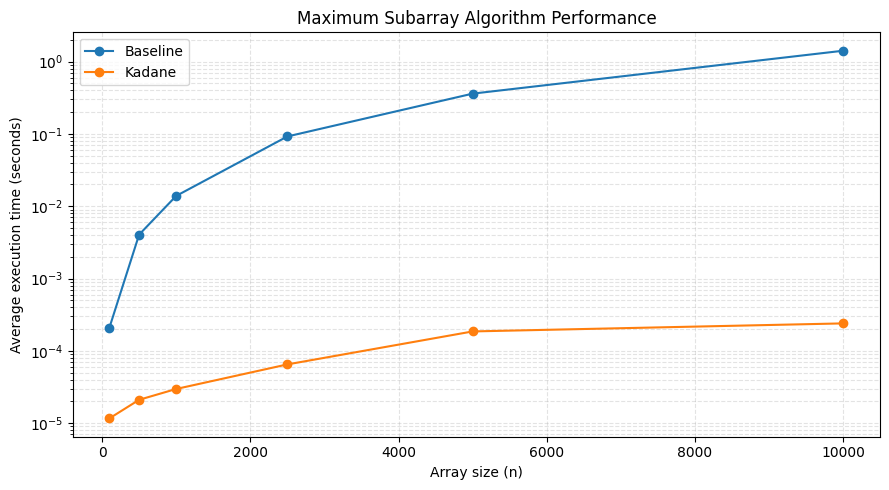

,Array size,Kadane (seconds)
0,100,0.000012
1,500,0.000021
2,1000,0.000030
3,2500,0.000065
4,5000,0.000185
5,10000,0.000239


In [ ]:
# Benchmark both algorithms on fresh random arrays.
def generate_array(size):
    return np.random.randint(-100, 101, size=size).tolist()

sizes = [100, 500, 1000, 2500, 5000, 10000]
repetitions = 5
benchmark_rows = []

for size in sizes:
    baseline_times = []
    kadane_times = []

    for _ in range(repetitions):
        values = generate_array(size)

        start = perf_counter()
        baseline_result = baseline_max_sublist(values)
        baseline_times.append(perf_counter() - start)

        start = perf_counter()
        kadane_result = kadane_max_subarray(values)
        kadane_times.append(perf_counter() - start)

        assert baseline_result == kadane_result

    benchmark_rows.append({
        "Array size": size,
        "Baseline (seconds)": np.mean(baseline_times),
        "Kadane (seconds)": np.mean(kadane_times),
    })

results = pd.DataFrame(benchmark_rows)
results

plt.figure(figsize=(9, 5))
plt.plot(results["Array size"], results["Baseline (seconds)"], marker="o", label="Baseline")
plt.plot(results["Array size"], results["Kadane (seconds)"], marker="o", label="Kadane")
plt.yscale("log")
plt.xlabel("Array size (n)")
plt.ylabel("Average execution time (seconds)")
plt.title("Maximum Subarray Algorithm Performance")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()
results[["Array size", "Baseline (seconds)"]]
results[["Array size", "Kadane (seconds)"]]